# Семинар 6: Image Segmentation

**План семинара:**

1. Обучаем UNet (с ResNet34 backbone) на маленьком датасете
2. Накручиваем FPN Decoder на ViT

In [26]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch import Tensor
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import segmentation_models_pytorch as smp
%matplotlib inline

## 1. Берем маленький простенький датасет как пример для семинара

Данные взяты с [Kaggle](https://www.kaggle.com/datasets/ztaihong/weizmann-horse-database?resource=download)

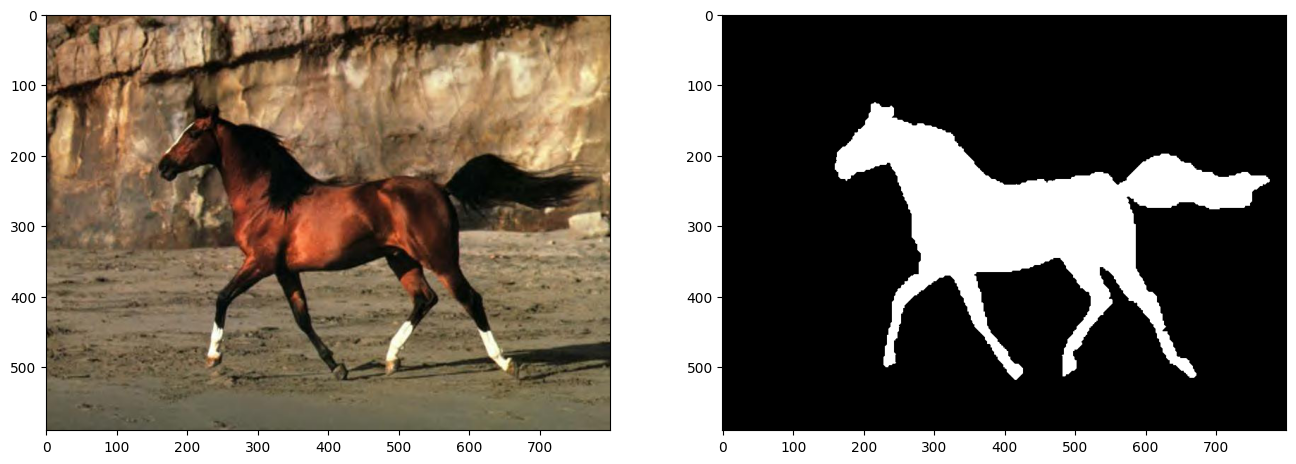

In [27]:
img = cv2.cvtColor(cv2.imread("seminar_data/weizmann_horse_db/horse/horse001.png"), cv2.COLOR_BGR2RGB)
mask = cv2.imread("seminar_data/weizmann_horse_db/mask/horse001.png")

fig, ax = plt.subplots(1, 2, figsize=(16,8))
ax[0].imshow(img)
ax[1].imshow(mask * 255)

In [28]:
class HorseDataset(Dataset):
    def __init__(self, root: str, size: int = 224) -> None:
        self.img_dir: str = os.path.join(root, "horse")
        self.mask_dir: str = os.path.join(root, "mask")
        self.files: list[str] = sorted(os.listdir(self.img_dir))
        self.size: int = size

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx: int) -> tuple[Tensor, Tensor]:
        name: str = self.files[idx]
        img_path: str = os.path.join(self.img_dir, name)
        mask_path: str = os.path.join(self.mask_dir, name)

        image: np.ndarray = cv2.imread(img_path)
        mask: np.ndarray = cv2.imread(mask_path, 0)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.size, self.size))
        mask = cv2.resize(mask, (self.size, self.size))

        mask = (mask > 0).astype(np.float32)
        image_tensor: Tensor = torch.tensor(image).permute(2, 0, 1).float() / 255.0
        mask_tensor: Tensor = torch.tensor(mask)

        return image_tensor, mask_tensor


def dice_score(pred: Tensor, target: Tensor, eps: float = 1e-6) -> float:
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    return ((2 * intersection + eps) / (union + eps)).item()


def iou_score(pred: Tensor, target: Tensor, eps: float = 1e-6) -> float:
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    union = (pred + target - pred * target).sum()
    return ((intersection + eps) / (union + eps)).item()

In [36]:
dataset = HorseDataset("seminar_data/weizmann_horse_db", size=224)

total_len = len(dataset)
train_len = int(0.7 * total_len)
val_len   = int(0.2 * total_len)
test_len  = total_len - train_len - val_len

train_ds, val_ds, test_ds = random_split(dataset, [train_len, val_len, test_len])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8)
test_loader  = DataLoader(test_ds, batch_size=8)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Train: 228, Val: 65, Test: 34


## Модель 1: UNet (c ResNet34 backbone)
Модель берем из [segmentation_models_pytorch](https://segmentation-modelspytorch.readthedocs.io/en/latest/)  
В библиотеке представлены стандартные архитектуры семантической сегментации + обширный список backbone, обученных на imagenet => большой выбор доступных конфигураций

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [38]:
EPOCHS: int = 15

for epoch in range(EPOCHS):
    model.train()
    total_loss: float = 0.0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.unsqueeze(1).to(device)
        preds = model(imgs)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Валидация после эпохи
    model.eval()
    dice_total = 0.0
    iou_total  = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.unsqueeze(1).to(device)
            preds = model(imgs)
            dice_total += dice_score(preds, masks)
            iou_total  += iou_score(preds, masks)
    model.train()

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {total_loss/len(train_loader):.4f} | "
          f"Val Dice: {dice_total/len(val_loader):.4f} | "
          f"Val IoU: {iou_total/len(val_loader):.4f}")

Epoch 1/15 | Train Loss: 0.2463 | Val Dice: 0.8903 | Val IoU: 0.8026
Epoch 2/15 | Train Loss: 0.1168 | Val Dice: 0.9123 | Val IoU: 0.8393
Epoch 3/15 | Train Loss: 0.0797 | Val Dice: 0.9308 | Val IoU: 0.8709
Epoch 4/15 | Train Loss: 0.0614 | Val Dice: 0.9413 | Val IoU: 0.8893
Epoch 5/15 | Train Loss: 0.0633 | Val Dice: 0.9395 | Val IoU: 0.8861
Epoch 6/15 | Train Loss: 0.0520 | Val Dice: 0.9465 | Val IoU: 0.8985
Epoch 7/15 | Train Loss: 0.0455 | Val Dice: 0.9393 | Val IoU: 0.8857
Epoch 8/15 | Train Loss: 0.0592 | Val Dice: 0.9200 | Val IoU: 0.8522
Epoch 9/15 | Train Loss: 0.0567 | Val Dice: 0.9406 | Val IoU: 0.8882
Epoch 10/15 | Train Loss: 0.0457 | Val Dice: 0.9432 | Val IoU: 0.8928
Epoch 11/15 | Train Loss: 0.0617 | Val Dice: 0.8740 | Val IoU: 0.7782
Epoch 12/15 | Train Loss: 0.0665 | Val Dice: 0.9340 | Val IoU: 0.8767
Epoch 13/15 | Train Loss: 0.0495 | Val Dice: 0.9486 | Val IoU: 0.9024
Epoch 14/15 | Train Loss: 0.0396 | Val Dice: 0.9506 | Val IoU: 0.9060
Epoch 15/15 | Train Loss: 0.0

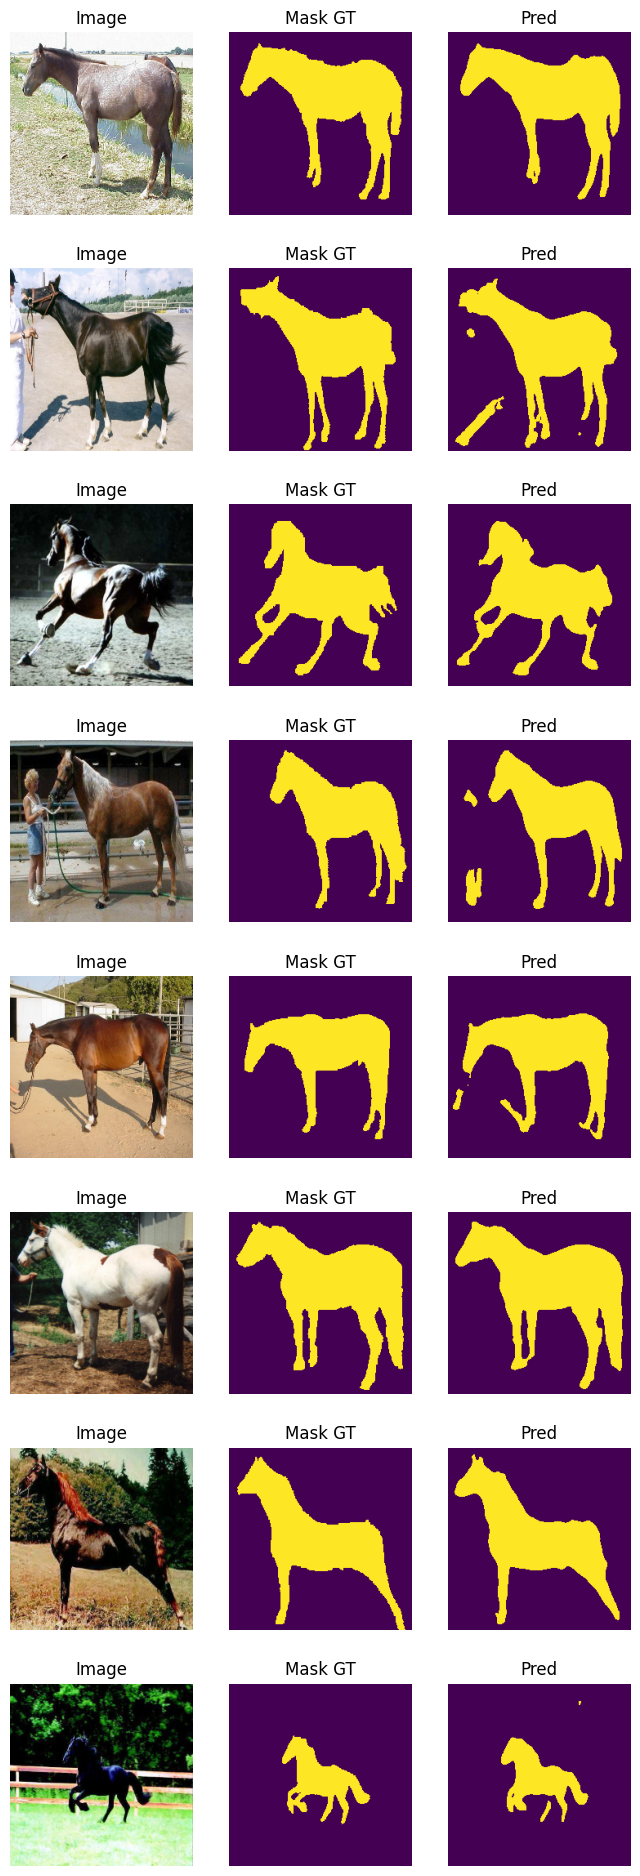

In [39]:
model.eval()
imgs, masks = next(iter(test_loader))
imgs = imgs.to(device)

with torch.no_grad():
    preds = model(imgs)

preds_np = (torch.sigmoid(preds).cpu().numpy() > 0.5)

fig, ax = plt.subplots(8, 3, figsize=(8,24))

for i in range(8):
    ax[i,0].imshow(imgs[i].cpu().permute(1,2,0))
    ax[i,0].set_title("Image")
    ax[i,1].imshow(masks[i])
    ax[i,1].set_title("Mask GT")
    ax[i,2].imshow(preds_np[i,0])
    ax[i,2].set_title("Pred")
    for j in range(3):
        ax[i,j].axis("off")

## Модель 2: FPN (ViT backbone)

 **Идея:** реализовать Vision Transformer (ViT) + FPN Decoder

 Вспомним:
 $$
 F = Concat(P_2, Up(P_3), Up(P_4), Up(P_5))
 $$

 $$
 y = Conv_{1\times1}(F)
 $$

 где:
 $$
 P_l = Conv_{3\times3}(Conv_{1\times1}(C_l) + Up(P_{l+1}))
 $$
 a $C_i$ получены из backbone

 ViT возвращает лишь последний feature map, поэтому вместо него мы возьмем BeiT

#### **ViT (Vision Transformer)**

- Классическая архитектура: изображение → патчи → линейное embedding → transformer-блоки
- **Особенности:**
    - Нет иерархии feature maps — все признаки имеют **один spatial resolution** (размер патча, например 16×16)
    - Выход после всех блоков: обычно **[CLS]-token или полный патч embedding**, используется для классификации
    - Semantic segmentation напрямую не поддерживает многоуровневую FPN
- Используется как **“чистый” Transformer** для изображений

---

#### **BEiT (BERT Pretrained Image Transformer)**

- Вдохновлён **BERT из NLP**, применён к изображениям
- Pretraining:
    - Masked Image Modeling (аналог Masked Language Modeling)
    - Модель учится предсказывать пропущенные патчи
- **Особенности архитектуры:**
    - Часто имеет **hierarchical feature maps** (разные уровни) — удобно для FPN и детекции
    - Использует более сложные токены и embedding с позиционными encoding
- BEiT → ViT + pretraining + иногда multi-scale output

In [51]:
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F

class ViTBackboneFPN(nn.Module):
    def __init__(self, backbone_name='beit_base_patch16_224', num_classes=1):
        super().__init__()
        
        # backbone с multi-scale features
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=True,
            features_only=True,
            out_indices=(0,1,2,3)  # 4 уровней
        )
        
        feats_info = self.backbone.feature_info
        channels = feats_info.channels()  # [256, 512, 1024, 2048] например
        
        # lateral 1x1 convs
        self.lats = nn.ModuleList([
            nn.Conv2d(ch, 256, 1) for ch in channels
        ])
        # smoothing 3x3 convs
        self.smooths = nn.ModuleList([
            nn.Conv2d(256, 256, 3, padding=1) for _ in channels
        ])
        
        # final output conv
        self.final = nn.Conv2d(256*4, num_classes, 1)

    def forward(self, x):
        feats = self.backbone(x)
        # feats: list [C2, C3, C4, C5]
        
        # top-down FPN
        P5 = self.smooths[3]( self.lats[3](feats[3]) )
        P4 = self.smooths[2]( self.lats[2](feats[2]) + F.interpolate(P5, size=feats[2].shape[2:], mode='bilinear', align_corners=False) )
        P3 = self.smooths[1]( self.lats[1](feats[1]) + F.interpolate(P4, size=feats[1].shape[2:], mode='bilinear', align_corners=False) )
        P2 = self.smooths[0]( self.lats[0](feats[0]) + F.interpolate(P3, size=feats[0].shape[2:], mode='bilinear', align_corners=False) )
        
        # concat to P2 size
        P3_up = F.interpolate(P3, size=P2.shape[2:], mode='bilinear', align_corners=False)
        P4_up = F.interpolate(P4, size=P2.shape[2:], mode='bilinear', align_corners=False)
        P5_up = F.interpolate(P5, size=P2.shape[2:], mode='bilinear', align_corners=False)
        
        cat = torch.cat([P2, P3_up, P4_up, P5_up], dim=1)
        out = self.final(cat)
        return out

In [52]:
import torch.nn as nn
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"

model = BEiT_FPN(num_classes=1).to(device)  # ваш ViT + FPN
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [55]:
EPOCHS = 25

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.unsqueeze(1).to(device)
        preds = model(imgs)
        preds = F.interpolate(preds, size=masks.shape[-2:], mode='bilinear', align_corners=False)
        loss = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Валидация
    model.eval()
    dice_total, iou_total = 0.0, 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.unsqueeze(1).to(device)
            preds = model(imgs)
            preds = F.interpolate(preds, size=masks.shape[-2:], mode='bilinear', align_corners=False)
            dice_total += dice_score(preds, masks)
            iou_total += iou_score(preds, masks)
    model.train()

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Val Dice: {dice_total/len(val_loader):.4f} | "
          f"Val IoU: {iou_total/len(val_loader):.4f}")

Epoch 1/25 | Train Loss: 0.1773 | Val Dice: 0.7978 | Val IoU: 0.6655
Epoch 2/25 | Train Loss: 0.1806 | Val Dice: 0.8039 | Val IoU: 0.6748
Epoch 3/25 | Train Loss: 0.1708 | Val Dice: 0.8032 | Val IoU: 0.6722
Epoch 4/25 | Train Loss: 0.1576 | Val Dice: 0.7999 | Val IoU: 0.6696
Epoch 5/25 | Train Loss: 0.1604 | Val Dice: 0.8122 | Val IoU: 0.6853
Epoch 6/25 | Train Loss: 0.1524 | Val Dice: 0.8155 | Val IoU: 0.6900
Epoch 7/25 | Train Loss: 0.1424 | Val Dice: 0.8164 | Val IoU: 0.6933
Epoch 8/25 | Train Loss: 0.1338 | Val Dice: 0.8154 | Val IoU: 0.6898
Epoch 9/25 | Train Loss: 0.1295 | Val Dice: 0.8264 | Val IoU: 0.7062
Epoch 10/25 | Train Loss: 0.1189 | Val Dice: 0.8143 | Val IoU: 0.6900
Epoch 11/25 | Train Loss: 0.1137 | Val Dice: 0.8398 | Val IoU: 0.7261
Epoch 12/25 | Train Loss: 0.1537 | Val Dice: 0.7952 | Val IoU: 0.6624
Epoch 13/25 | Train Loss: 0.1528 | Val Dice: 0.8079 | Val IoU: 0.6828
Epoch 14/25 | Train Loss: 0.1319 | Val Dice: 0.8112 | Val IoU: 0.6859
Epoch 15/25 | Train Loss: 0.1

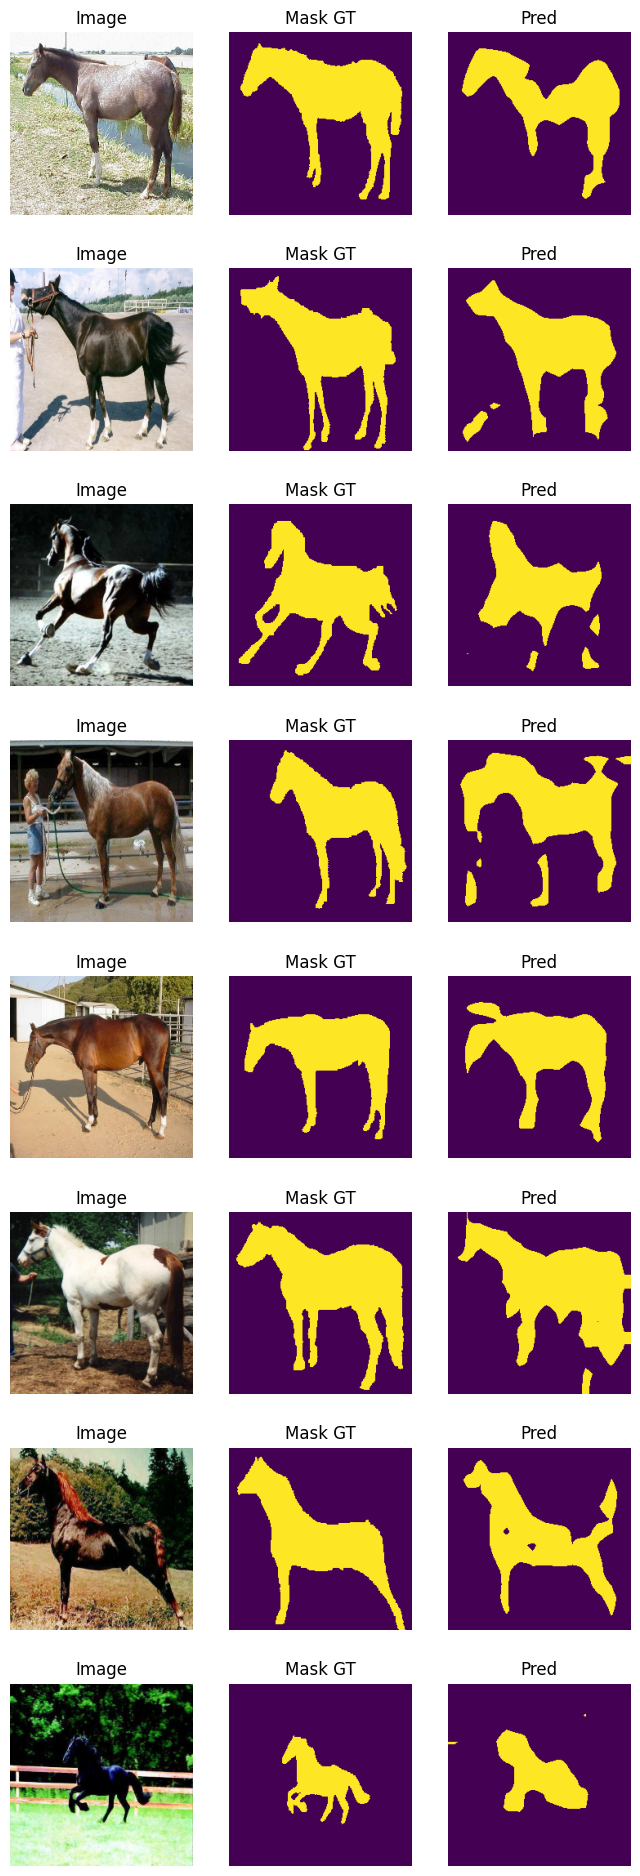

In [56]:
model.eval()
imgs, masks = next(iter(test_loader))
imgs = imgs.to(device)

with torch.no_grad():
    preds = model(imgs)
    preds = F.interpolate(preds, size=masks.shape[-2:], mode='bilinear', align_corners=False)

preds_np = (torch.sigmoid(preds).cpu().numpy() > 0.5)

fig, ax = plt.subplots(8, 3, figsize=(8,24))

for i in range(8):
    ax[i,0].imshow(imgs[i].cpu().permute(1,2,0))
    ax[i,0].set_title("Image")
    ax[i,1].imshow(masks[i])
    ax[i,1].set_title("Mask GT")
    ax[i,2].imshow(preds_np[i,0])
    ax[i,2].set_title("Pred")
    for j in range(3):
        ax[i,j].axis("off")

#### Почему результаты хуже

1. **Spatial resolution**
    - BEiT разбивает 224×224 изображение на патчи 16×16 → 14×14 feature map
    - Даже с FPN, апсемплинг обратно до 224×224 → границы объектов остаются “размытые”
    - Малые объекты плохо выделяются
2. **Малый датасет**
    - 328 изображений → трансформер тяжело обучется, тяжело обучать топ‑down pathway
    - Даже с заморозкой FPN и head скорее всего быстро подгонят выход под датасет → сомнительный вариант
3. **Skip connections**
    - В классическом Unet есть **точные skip connections** на всех уровнях → сохраняют локальные детали
    - BEiT‑FPN пока использует только латеральные связи с high-level features → мелкие детали теряются

---

#### Что можно сделать, чтобы улучшить маски

1. **MLA‑подход** (как в SETR‑MLA):
    - Использовать промежуточные фичи из **нескольких блоков BEiT**, не только последние 4 уровня
    - Refinment для уточнения деталей
2. **Добавить lightweight decoder**:
    - После FPN сделать 2–3 conv+upsample блока, чтобы **постепенно увеличить разрешение**, а не сразу 14→224
3. **Использовать сильные аугментации + mixup / cutmix**
    - Помогает трансформеру лучше учиться на маленьком dataset


#### Вывод:

- На маленьком датасете **никакой BEiT‑FPN не даст маски как Unet+ResNet**, если делать прямой апсемпл без fine-grained decoder
- Чтобы BEiT‑FPN был близок к Unet по качеству, нужен **легкий декодер, MLA, post-processing**